
##  Loading the Dataset 

### Enviroment SetUP

In [37]:
%pip install pandas numpy matplotlib  

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
### Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Loading the Dataset

In [10]:

df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [12]:
### Binarize the target column: 1 = disease present, 0 = no disease

df["target"] = df["target"].apply(
    lambda v: 1 if v in (1, "yes", "Yes", "True", "present") else 0
).astype(int)

print(df["target"].value_counts())
print("dtype:", df["target"].dtype)

target
1    526
0    499
Name: count, dtype: int64
dtype: int64


In [16]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

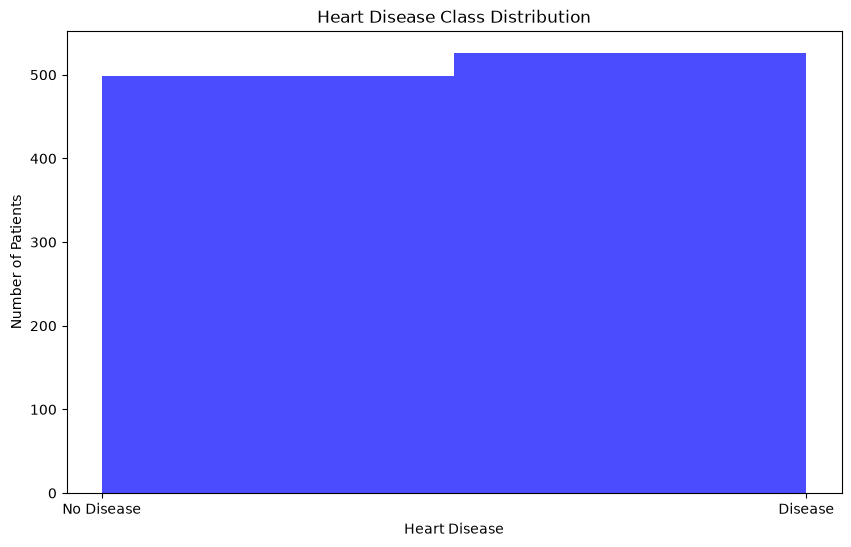

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(df["target"], bins=2, color="blue", alpha=0.7)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

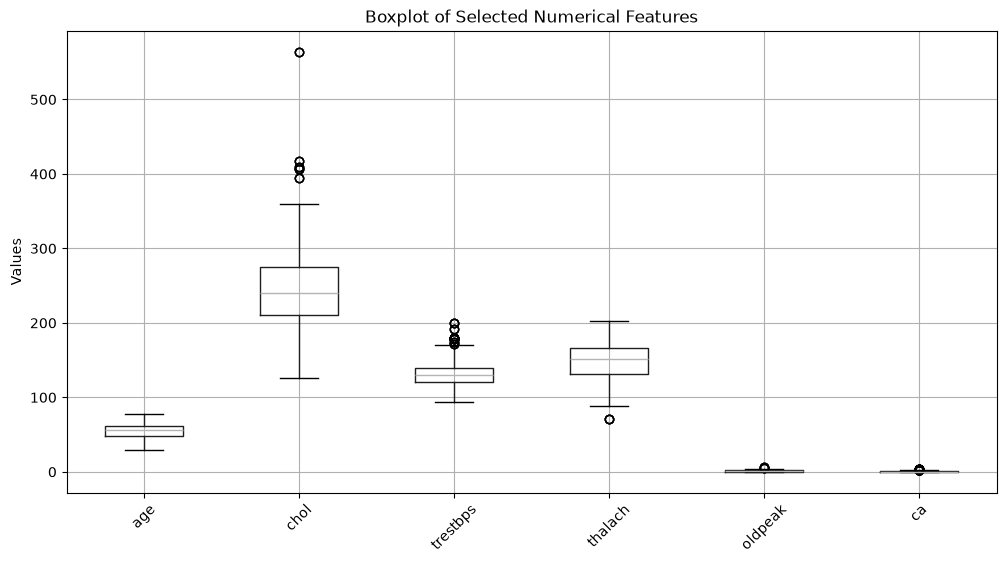

In [21]:
features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

plt.figure(figsize=(12, 6))

df[features].boxplot()

plt.title("Boxplot of Selected Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.show()

In [33]:
features = [
    "age",
    "chol",
    "trestbps",
    "thalach",
    "oldpeak",
    "ca"
]

X = df[features]
y = df["target"]

In [35]:
np.random.seed(42)

indices_0 = df[df["target"] == 0].index.to_numpy().copy()
indices_1 = df[df["target"] == 1].index.to_numpy().copy()

np.random.shuffle(indices_0)
np.random.shuffle(indices_1)

split_0 = int(len(indices_0) * 0.70)
split_1 = int(len(indices_1) * 0.70)

train_indices = np.concatenate([
    indices_0[:split_0],
    indices_1[:split_1]
])

test_indices = np.concatenate([
    indices_0[split_0:],
    indices_1[split_1:]
])

X_train = df.loc[train_indices, features]
X_test = df.loc[test_indices, features]

y_train = df.loc[train_indices, "target"]
y_test = df.loc[test_indices, "target"]

In [36]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training: (717, 6)
Test: (308, 6)

Training distribution:
target
1    368
0    349
Name: count, dtype: int64

Test distribution:
target
1    158
0    150
Name: count, dtype: int64


## Logistic Regression

In [38]:
def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))


In [39]:
def compute_cost(w, b, X, y):
    """Compute logistic regression cost J(w, b) using explicit model."""
    m, n = X.shape

    z = X @ w + b
    f = sigmoid(z)

    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    
    return J

In [40]:
def compute_gradient(w, b, X, y):
    """Compute the gradient of the cost function with respect to w and b."""
    m, n = X.shape

    z = X @ w + b
    f = sigmoid(z)

    error = f - y
    

    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

In [41]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    """Perform gradient descent to learn w and b."""
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i % 100 == 0:
            J_history.append(compute_cost(w, b, X, y))
            print(f"Iteration {i}: Cost {J_history[-1]}")

    return w, b, J_history

In [ ]:
print("Training the logistic regression model...")
print(J_history[-1])

In [43]:
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std

In [44]:
## Training the logistic regression model
w_initial = np.zeros(6)
b_initial = 0
alpha = 0.01
iterations = 1000
w, b, J_history = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations)

Iteration 0: Cost 0.6916416071363646
Iteration 100: Cost 0.594426348143654
Iteration 200: Cost 0.5525569917789851
Iteration 300: Cost 0.5313550526270656
Iteration 400: Cost 0.5191817458329218
Iteration 500: Cost 0.5115327336275779
Iteration 600: Cost 0.5063997926725847
Iteration 700: Cost 0.5027817063194951
Iteration 800: Cost 0.5001338891620237
Iteration 900: Cost 0.4981388905941204


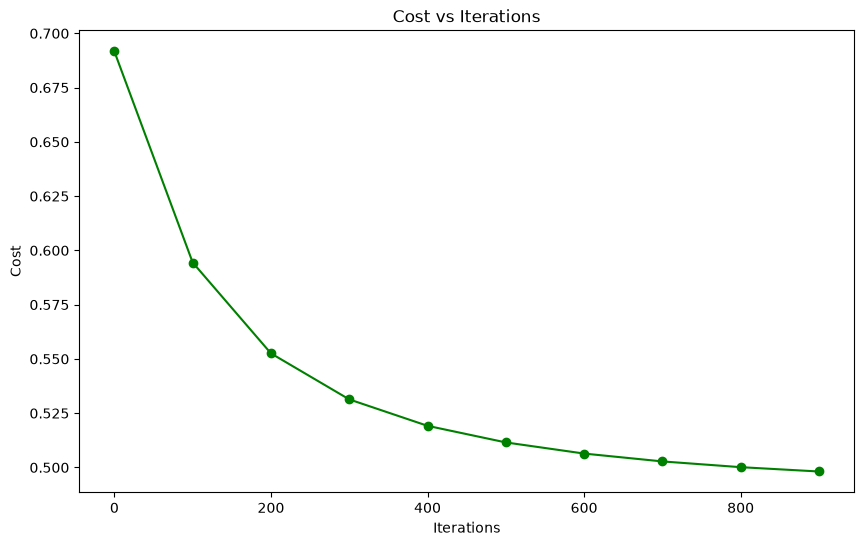

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(range(0, iterations, 100), J_history, marker='o', color='green')
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


In [49]:
def prediction(X, w, b):
    """Predict the class labels for input data X using learned parameters w and b."""
    z = X @ w + b
    f = sigmoid(z)
    return (f >= 0.5).astype(int)

In [50]:
def accuracy(y_true, y_pred):
    """Compute the accuracy of predictions."""
    return np.mean(y_true == y_pred) * 100

In [51]:
def precision(y_true, y_pred):
    """Compute the precision of predictions."""
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    predicted_positive = np.sum(y_pred == 1)
    return true_positive / predicted_positive if predicted_positive > 0 else 0

In [52]:
def recall(y_true, y_pred):
    """Compute the recall of predictions."""
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    actual_positive = np.sum(y_true == 1)
    return true_positive / actual_positive if actual_positive > 0 else 0

In [53]:
def F1_score(y_true, y_pred):
    """Compute the F1 score of predictions."""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0

In [54]:
y_pred_train = prediction(X_train_scaled.to_numpy(), w, b)
y_pred_test = prediction(((X_test - mean) / std).to_numpy(), w, b)
print("training set")
print(f"Accuracy: {accuracy(y_train.to_numpy(), y_pred_train):.2f}%")
print(f"Precision: {precision(y_train.to_numpy(), y_pred_train):.2f}")
print(f"Recall: {recall(y_train.to_numpy(), y_pred_train):.2f}")
print(f"F1 Score: {F1_score(y_train.to_numpy(), y_pred_train):.2f}")
print("\ntest set")
print(f"Accuracy: {accuracy(y_test.to_numpy(), y_pred_test):.2f}%")
print(f"Precision: {precision(y_test.to_numpy(), y_pred_test):.2f}")
print(f"Recall: {recall(y_test.to_numpy(), y_pred_test):.2f}")
print(f"F1 Score: {F1_score(y_test.to_numpy(), y_pred_test):.2f}")

training set
Accuracy: 73.92%
Precision: 0.73
Recall: 0.79
F1 Score: 0.76

test set
Accuracy: 75.32%
Precision: 0.74
Recall: 0.79
F1 Score: 0.77


3.

In [56]:

np.random.seed(42)
indices_2= df[df["target"] == 0].index.to_numpy().copy()
indices_3 = df[df["target"] == 1].index.to_numpy().copy()
np.random.shuffle(indices_2)
np.random.shuffle(indices_3)
split_2 = int(len(indices_2) * 0.70)
split_3 = int(len(indices_3) * 0.70)
train_indices = np.concatenate([
    indices_2[:split_2],
    indices_3[:split_3]
])
test_indices = np.concatenate([
    indices_2[split_2:],
    indices_3[split_3:]
])
X_train_pair_1 = df.loc[train_indices, ['age', 'chol']]
X_test_pair_1 = df.loc[test_indices, ['age', 'chol']]
y_train_pair_1 = df.loc[train_indices, "target"]
y_test_pair_1 = df.loc[test_indices, "target"]


In [57]:
mean_pair = X_train_pair_1.mean()
std_pair = X_train_pair_1.std()
X_train_pair_scaled = (X_train_pair_1 - mean_pair) / std_pair
X_test_pair_scaled = (X_test_pair_1 - mean_pair) / std_pair

In [58]:
w_initial_pair_1 = np.zeros(2)
b_initial_pair_1 = 0
alpha = 0.01
iterations = 1000
w_pair_1,b_pair_1,J_history_pair_1 = gradient_descent(X_train_pair_scaled.to_numpy(), y_train_pair_1.to_numpy(), w_initial_pair_1, b_initial_pair_1, alpha, iterations)

Iteration 0: Cost 0.6929576887930781
Iteration 100: Cost 0.67866537790694
Iteration 200: Cost 0.6706409432037975
Iteration 300: Cost 0.6660477053877383
Iteration 400: Cost 0.6633640526921174
Iteration 500: Cost 0.6617659013405631
Iteration 600: Cost 0.6607978316334308
Iteration 700: Cost 0.6602025207518726
Iteration 800: Cost 0.6598314948326639
Iteration 900: Cost 0.6595974547903181


In [63]:
def plot_linear_data_with_boundary(w, b, X, y, title):
    plt.figure()
    plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", label="y = 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="x", label="y = 1")

    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    if abs(w[1]) > 1e-6:
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        plt.plot(x1_vals, x2_vals, "k--", label="decision boundary")
    else:
        x1_line = -b / w[0]
        plt.axvline(x1_line, color="k", linestyle="--", label="decision boundary")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


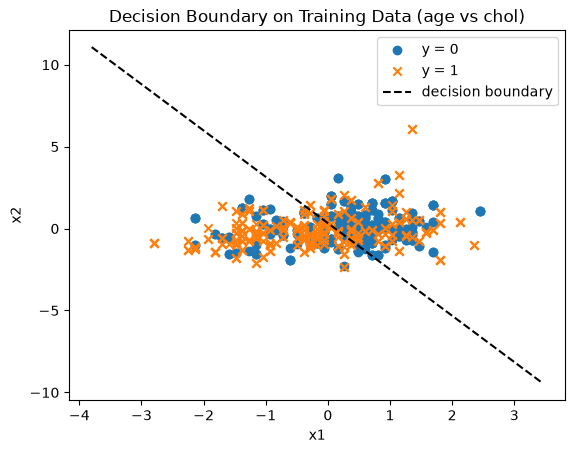

In [64]:
plot_linear_data_with_boundary(
    w_pair_1, b_pair_1, X_train_pair_scaled.to_numpy(), y_train_pair_1.to_numpy(), "Decision Boundary on Training Data (age vs chol)"
)

In [65]:
np.random.seed(42)
indices_4= df[df["target"] == 0].index.to_numpy().copy()
indices_5 = df[df["target"] == 1].index.to_numpy().copy()
np.random.shuffle(indices_4)
np.random.shuffle(indices_5)
split_4 = int(len(indices_4) * 0.70)
split_5 = int(len(indices_5) * 0.70)
train_indices_2 = np.concatenate([
    indices_4[:split_4],
    indices_5[:split_5]
])
test_indices_2 = np.concatenate([
    indices_4[split_4:],
    indices_5[split_5:]
])
X_train_pair_4 = df.loc[train_indices_2, ['trestbps', 'thalach']]
X_test_pair_4 = df.loc[test_indices_2, ['trestbps', 'thalach']]
y_train_pair_4 = df.loc[train_indices_2, "target"]
y_test_pair_4 = df.loc[test_indices_2, "target"]


In [66]:
mean_pair = X_train_pair_4.mean()
std_pair = X_train_pair_4.std()
X_train_pair_scaled_4 = (X_train_pair_4 - mean_pair) / std_pair
X_test_pair_scaled_4 = (X_test_pair_4 - mean_pair) / std_pair

In [67]:
w_initial_pair_4 = np.zeros(2)
b_initial_pair_4 = 0
alpha = 0.01
iterations = 1000
w_pair_4,b_pair_4,J_history_pair_4 = gradient_descent(X_train_pair_scaled_4.to_numpy(), y_train_pair_4.to_numpy(), w_initial_pair_4, b_initial_pair_4, alpha, iterations)

Iteration 0: Cost 0.6926455634580391
Iteration 100: Cost 0.6534504746368222
Iteration 200: Cost 0.6296335608714037
Iteration 300: Cost 0.6147740479906494
Iteration 400: Cost 0.6052331814404844
Iteration 500: Cost 0.598945382703215
Iteration 600: Cost 0.5947080818724986
Iteration 700: Cost 0.5917988650780996
Iteration 800: Cost 0.5897702654294643
Iteration 900: Cost 0.5883373453366836


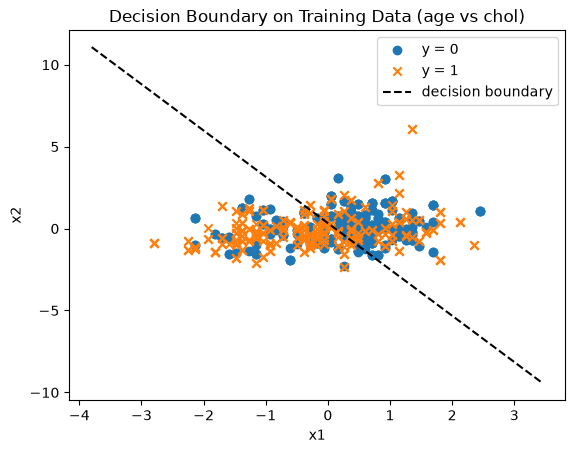

In [68]:
plot_linear_data_with_boundary(
    w_pair_1, b_pair_1, X_train_pair_scaled.to_numpy(), y_train_pair_1.to_numpy(), "Decision Boundary on Training Data (age vs chol)"
)

In [70]:
np.random.seed(42)
indices_6= df[df["target"] == 0].index.to_numpy().copy()
indices_7 = df[df["target"] == 1].index.to_numpy().copy()
np.random.shuffle(indices_6)
np.random.shuffle(indices_7)
split_6 = int(len(indices_6) * 0.70)
split_7 = int(len(indices_7) * 0.70)
train_indices_3 = np.concatenate([
    indices_6[:split_6],
    indices_7[:split_7]
])
test_indices_3 = np.concatenate([
    indices_6[split_6:],
    indices_7[split_7:]
])
X_train_pair_5 = df.loc[train_indices_3, ['oldpeak', 'ca']]
X_test_pair_5 = df.loc[test_indices_3, ['oldpeak', 'ca']]
y_train_pair_5 = df.loc[train_indices_3, "target"]
y_test_pair_5 = df.loc[test_indices_3, "target"]


In [71]:
mean_pair = X_train_pair_5.mean()
std_pair = X_train_pair_5.std()
X_train_pair_scaled_5 = (X_train_pair_5 - mean_pair) / std_pair
X_test_pair_scaled_5 = (X_test_pair_5 - mean_pair) / std



In [72]:
w_initial_pair = np.zeros(2)
b_initial_pair = 0
alpha = 0.01
iterations = 1000
w_pair_5,b_pair_5,J_history_pair_5 = gradient_descent(X_train_pair_scaled_5.to_numpy(), y_train_pair_5.to_numpy(), w_initial_pair, b_initial_pair, alpha, iterations)

Iteration 0: Cost 0.6923277505621303
Iteration 100: Cost 0.6311515224933228
Iteration 200: Cost 0.5968216720119495
Iteration 300: Cost 0.5763594508425858
Iteration 400: Cost 0.563487214078717
Iteration 500: Cost 0.5550334316266358
Iteration 600: Cost 0.549287828046434
Iteration 700: Cost 0.5452730681631666
Iteration 800: Cost 0.5424031229198075
Iteration 900: Cost 0.540312294578303


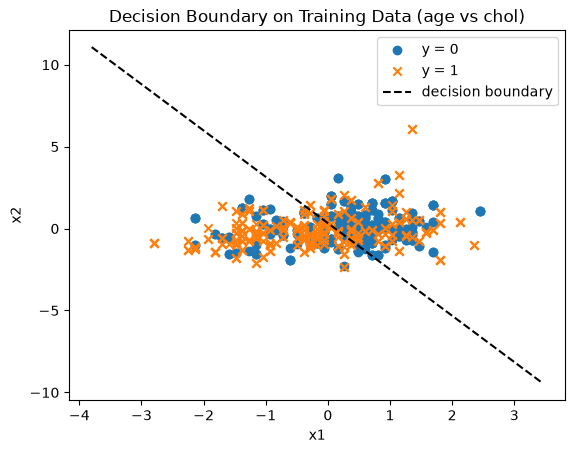

In [73]:
plot_linear_data_with_boundary(
    w_pair_1, b_pair_1, X_train_pair_scaled.to_numpy(), y_train_pair_1.to_numpy(), "Decision Boundary on Training Data (age vs chol)"
)

4


In [74]:
def compute_cost(w, b, x, y, lam):
    m, n = x.shape
    z = x @ w + b
    f = sigmoid(z)
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps) 
    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped))
    reg_term = (lam / (2 * m)) * np.sum(w ** 2)
    return J + reg_term

In [75]:
def compute_gradient(w, b, x, y, lam):
    m, n = x.shape
    z = x @ w + b
    f = sigmoid(z)
    error = f - y   
    dj_dw = (1 / m) * (x.T @ error) + (lam / m) * w
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

In [76]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, lam):
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y, lam)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        J_history.append(compute_cost(w, b, X, y, lam))

    return w, b, J_history  

In [78]:
lam = 0
w_initial = np.zeros(X_train.shape[1])
b_initial = 0
w_reg, b_reg, J_history_reg = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations, lam)
print(f"Final cost: {J_history_reg[-1]}")

Final cost: 0.4966145110140749


In [79]:
lam = 0.001
w_initial = np.zeros(X_train.shape[1])
b_initial = 0
w_reg, b_reg, J_history_reg = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations, lam)
print(f"Final cost: {J_history_reg[-1]}")

Final cost: 0.49661555449459616


In [80]:
lam = 0.01
w_initial = np.zeros(X_train.shape[1])
b_initial = 0
w_reg, b_reg, J_history_reg = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations, lam)
print(f"Final cost: {J_history_reg[-1]}")

Final cost: 0.49662494517992883


In [81]:
lam = 0.1
w_initial = np.zeros(X_train.shape[1])
b_initial = 0
w_reg, b_reg, J_history_reg = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations, lam)
print(f"Final cost: {J_history_reg[-1]}")

Final cost: 0.496718788781105


In [82]:
lam = 1
w_initial = np.zeros(X_train.shape[1])
b_initial = 0
W_reg, b_reg, J_history_reg = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations, lam)
print(f"Final cost: {J_history_reg[-1]}")

Final cost: 0.497650943570401


In [83]:
np.linalg.norm(w_reg)

np.float64(1.1009841444315165)

In [91]:
lambda_values = [0, 0.001, 0.01, 0.1, 1]

X_test_scaled = (X_test - mean) / std

results = []

for lam in lambda_values:
    w_initial = np.zeros(X_train.shape[1])
    b_initial = 0

    w_reg, b_reg, J_history_reg = gradient_descent(
        X_train_scaled.to_numpy(),
        y_train.to_numpy(),
        w_initial,
        b_initial,
        alpha,
        iterations,
        lam
    )

    y_pred_train = prediction(
        X_train_scaled.to_numpy(),
        w_reg,
        b_reg
    )

    y_pred_test = prediction(
        X_test_scaled.to_numpy(),
        w_reg,
        b_reg
    )

    acc = accuracy(y_test.to_numpy(), y_pred_test)
    prec = precision(y_test.to_numpy(), y_pred_test)
    rec = recall(y_test.to_numpy(), y_pred_test)
    f1 = F1_score(y_test.to_numpy(), y_pred_test)

    w_norm = np.linalg.norm(w_reg)

    results.append([lam, acc, prec, rec, f1, w_norm])

print("Lambda | Accuracy | Precision | Recall | F1 | ||w||")
print("-" * 60)

for result in results:
    print(
        f"{result[0]:.3f}   | "
        f"{result[1]:.2f}%    | "
        f"{result[2]:.2f}      | "
        f"{result[3]:.2f}   | "
        f"{result[4]:.2f} | "
        f"{result[5]:.4f}"
    )

Lambda | Accuracy | Precision | Recall | F1 | ||w||
------------------------------------------------------------
0.000   | 75.32%    | 0.74      | 0.79   | 0.77 | 1.1015
0.001   | 75.32%    | 0.74      | 0.79   | 0.77 | 1.1015
0.010   | 75.32%    | 0.74      | 0.79   | 0.77 | 1.1015
0.100   | 75.32%    | 0.74      | 0.79   | 0.77 | 1.1010
1.000   | 75.32%    | 0.74      | 0.79   | 0.77 | 1.0960
